In [ ]:
import yfinance as yf
import pandas as pd
from google.colab import drive
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, SimpleRNN, Dropout
import os
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error


In [ ]:
# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define path and ensure the directory exists
# This assumes the folder 'lulap' is in your main 'My Drive'
folder_path = '/content/drive/MyDrive/lulap'
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# 3. Fetch S&P 500 historical data
ticker = "^GSPC"
sp500 = yf.Ticker(ticker)
hist = sp500.history(period="max")

# 4. Process data: Keep 'Close' and calculate 'Returns'
# Formula: (Price_t / Price_t-1) - 1
df = hist[['Close']].copy()
df['Returns'] = df['Close'].pct_change()
print (df.shape)
# 5. Save to CSV in the specified Drive folder
file_path = os.path.join(folder_path, 'SP500_close_returns.csv')
df.to_csv(file_path)

print(f"File successfully saved to: {file_path}")

Mounted at /content/drive
(24691, 2)
File successfully saved to: /content/drive/MyDrive/lulap/SP500_close_returns.csv


In [ ]:
ticker = "^GSPC"
# Fetch historical data
sp500 = yf.Ticker(ticker)
hist = sp500.history(period="max")
# Save to CSV
hist.to_csv("SP500_historical_data.csv")
print("S&P 500 data saved to SP500_historical_data.csv")
print (hist.shape)

S&P 500 data saved to SP500_historical_data.csv
(24691, 7)


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/lulap/SP500_close_returns.csv', index_col=0)
df.dropna(inplace=True)

def prepare_data(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

# Hyperparameters
window_size = 60 # Use last 60 days to predict the next
split = int(len(df) * 0.8)

In [ ]:
# LSTM
model_path_lstm = '/content/drive/MyDrive/lulap/sp500_lstm_model.keras'
def build_model(model_type, input_shape):
    model = Sequential()
    if model_type == 'RNN':
        model.add(SimpleRNN(50, activation='tanh', input_shape=input_shape))
    elif model_type == 'LSTM':
        model.add(LSTM(50, activation='tanh', input_shape=input_shape))

    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# Example for Close Prices
scaler_close = MinMaxScaler()
scaled_close = scaler_close.fit_transform(df[['Close']])
X_c, y_c = prepare_data(scaled_close, window_size)

# Split into Train/Test
X_train_c, X_test_c = X_c[:split], X_c[split:]
y_train_c, y_test_c = y_c[:split], y_c[split:]

# Train LSTM for Close
lstm_close = build_model('LSTM', (window_size, 1))
lstm_close.fit(X_train_c, y_train_c, epochs=10, batch_size=32, verbose=0)
lstm_close.save(model_path_lstm)
del lstm_close

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
Corrected Average Error: $24.77


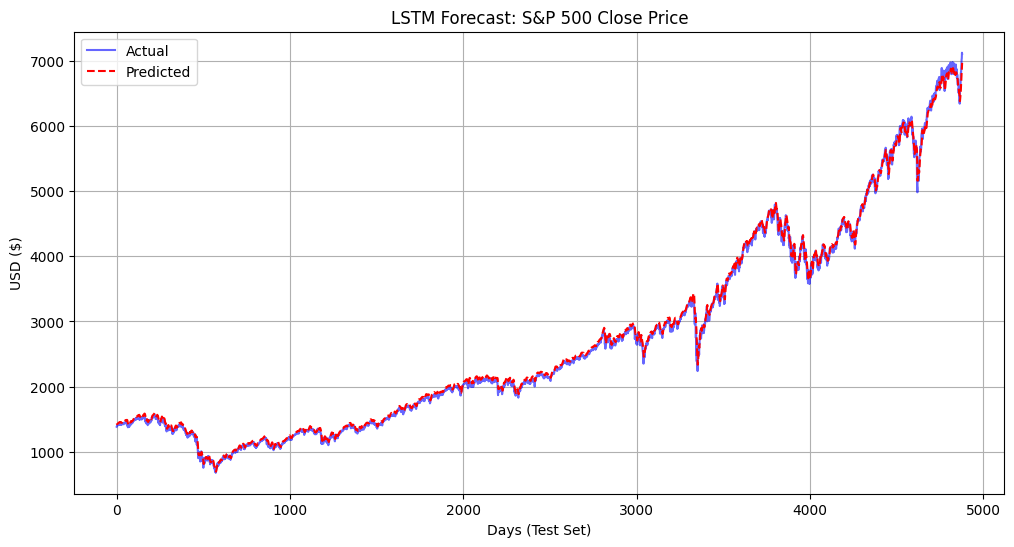

In [ ]:
def plot_results(actual, predicted, title, ylabel):
    plt.figure(figsize=(12, 6))
    plt.plot(actual, label='Actual', color='blue', alpha=0.6)
    plt.plot(predicted, label='Predicted', color='red', linestyle='--')
    plt.title(title)
    plt.xlabel('Days (Test Set)')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()

lstm_close = load_model(model_path_lstm)
preds_close_scaled = lstm_close.predict(X_test_c)

# Inverse transform ONCE to get USD
# We ensure y_test_c is shaped correctly (N, 1)
actual_close_usd = scaler_close.inverse_transform(y_test_c.reshape(-1, 1))
preds_close_usd = scaler_close.inverse_transform(preds_close_scaled)

# Calculate MAE (Average magnitude of error)
mae_lstm_c = mean_absolute_error(actual_close_usd, preds_close_usd)
# Calculate Bias (Actual average error: Predicted - Actual)
avg_error_lstm_c = np.mean(preds_close_usd - actual_close_usd)

print(f"Corrected Average Error: ${avg_error_lstm_c:.2f}")

# print(f"Close Price - LSTM: ${mae_lstm_c:.2f}")

plot_results(actual_close_usd, preds_close_usd, "LSTM Forecast: S&P 500 Close Price", "USD ($)")

In [ ]:

# 1. Define paths for the Returns models
model_path_lstm_ret = '/content/drive/MyDrive/lulap/sp500_lstm_returns.keras'
model_path_rnn_ret = '/content/drive/MyDrive/lulap/sp500_rnn_returns.keras'

# 2. Scale the Returns data
# Note: Returns usually have outliers, so we drop NaNs first
df_ret = df[['Returns']].dropna()
scaler_ret = MinMaxScaler()
scaled_ret = scaler_ret.fit_transform(df_ret)

# 3. Prepare data sequences
X_r, y_r = prepare_data(scaled_ret, window_size)
X_train_r, X_test_r = X_r[:split], X_r[split:]
y_train_r, y_test_r = y_r[:split], y_r[split:]

# 4. Train and Save LSTM for Returns
print("Training LSTM for Returns...")
lstm_ret = build_model('LSTM', (window_size, 1))
lstm_ret.fit(X_train_r, y_train_r, epochs=10, batch_size=32, verbose=0)
lstm_ret.save(model_path_lstm_ret)
del lstm_ret

# 5. Train and Save RNN for Returns
print("Training RNN for Returns...")
rnn_ret = build_model('RNN', (window_size, 1))
rnn_ret.fit(X_train_r, y_train_r, epochs=10, batch_size=32, verbose=0)
rnn_ret.save(model_path_rnn_ret)
del rnn_ret

print("Done! Both models for Returns are saved in Drive.")

Training LSTM for Returns...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training RNN for Returns...
Done! Both models for Returns are saved in Drive.


153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


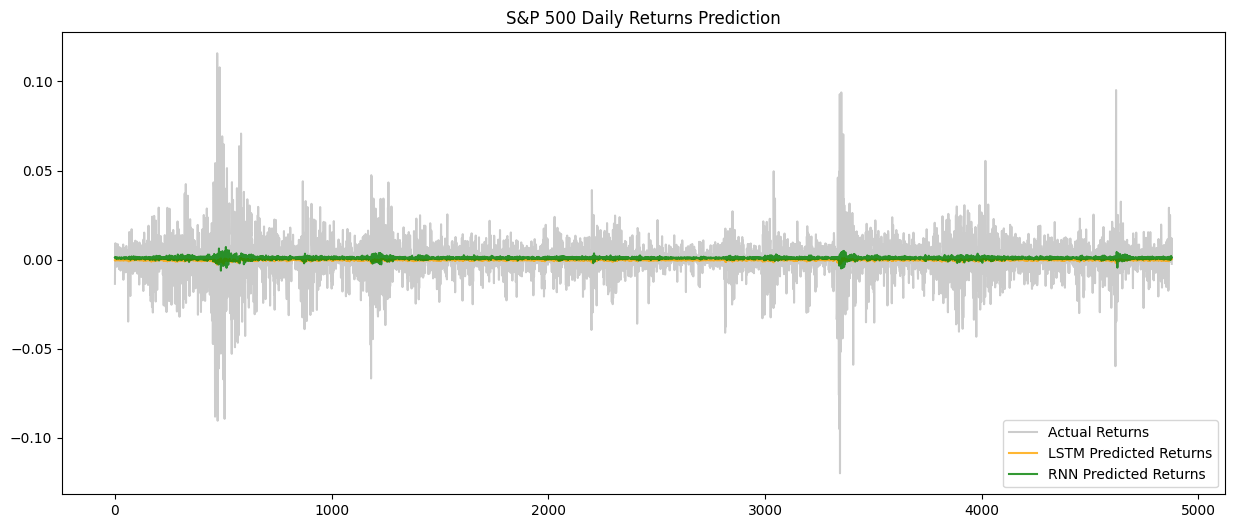

In [ ]:
# Load and Predict
loaded_lstm_ret = load_model(model_path_lstm_ret)
loaded_rnn_ret = load_model(model_path_rnn_ret)

preds_lstm_r = loaded_lstm_ret.predict(X_test_r)
preds_rnn_r = loaded_rnn_ret.predict(X_test_r)

# Inverse transform to get back to actual percentage returns
actual_ret = scaler_ret.inverse_transform(y_test_r)
final_lstm_r = scaler_ret.inverse_transform(preds_lstm_r)
final_rnn_r = scaler_ret.inverse_transform(preds_rnn_r)

# Visualization
plt.figure(figsize=(15, 6))
plt.plot(actual_ret, label='Actual Returns', color='gray', alpha=0.4)
plt.plot(final_lstm_r, label='LSTM Predicted Returns', color='orange', alpha=0.8)
plt.plot(final_rnn_r, label='RNN Predicted Returns', color='green', alpha=0.8)
plt.title('S&P 500 Daily Returns Prediction')
plt.legend()
plt.show()